# 支持向量机（SVM）实验

## 实验目的：
掌握SVM的原理和学习算法。
## 实验要求：
编程分别实现分类任务和回归任务的学习算法。

## 第一部分：分类任务（SVM）
结合搜索引擎阅读并理解以下代码。

使用不同的核值（线性SVM和非线性SVM）实现SVM学习算法。

回答问题：不同的核值之间有什么区别？

可选步骤：使用不同的“C”值实现SVM学习算法。

**注意，请将以下代码中random_state替换为自己学号的后四位。**

In [4]:
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [5]:
X = np.array([[1,1],[2,1],[1,2],[1.5,1.5],[3,4],[2,5],[4,3],[7,2],[3,5],[2,6],[6,2],[3,4],[4,4]])
y = [0,0,0,0,1,1,1,1,1,1,1,1,1]

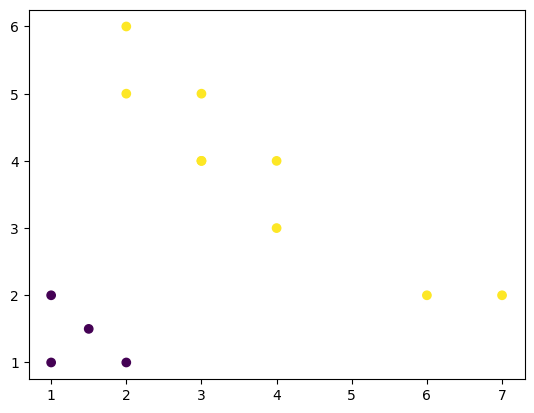

In [6]:
X_x1 = X[:,0]
X_x2 = X[:,1]
plt.scatter(X_x1, X_x2, c = y)
plt.show()

In [7]:
svcLinear =  SVC(kernel='linear').fit(X, y)
svcLinear.coef_, svcLinear.intercept_

(array([[0.49989823, 0.49989823]]), array([-2.49953185]))

$g(x) = w_1 x_1 + w_2 x_2 + w_0$

$x_2 = -(w_0 + w_1 x_1)/w_2$

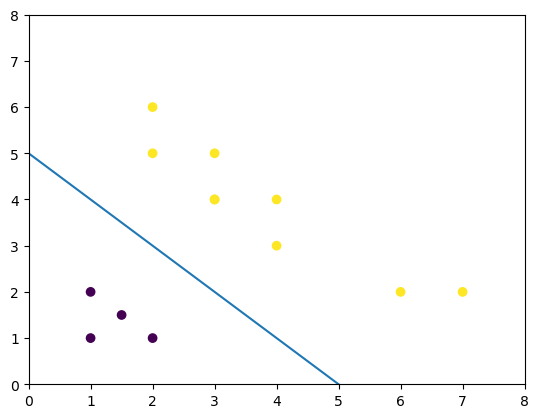

In [ ]:
x1 = np.array([0, 5])
x2 = -1 *(svcLinear.intercept_ + svcLinear.coef_[0][0] * x1)/svcLinear.coef_[0][1]
plt.plot(x1, x2)
plt.scatter(X_x1, X_x2, c = y)
plt.axis([0, 8, 0, 8])
plt.show()

Classification on iris dataset

In [9]:
from sklearn import svm, datasets
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [10]:
data = datasets.load_iris()
x = data.data[:,0:2]
y = data.target

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=31)

In [12]:
y_train

array([2, 1, 0, 2, 2, 0, 1, 1, 0, 0, 1, 2, 2, 0, 0, 1, 2, 0, 1, 0, 1, 2,
       0, 0, 2, 0, 2, 0, 1, 0, 2, 0, 1, 2, 0, 1, 1, 0, 0, 1, 1, 2, 2, 2,
       1, 1, 0, 2, 1, 0, 0, 2, 0, 0, 0, 1, 1, 2, 2, 0, 2, 0, 0, 2, 1, 0,
       1, 2, 2, 0, 1, 2, 0, 1, 0, 1, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1, 2, 2,
       1, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 0, 1, 0, 0, 2, 1, 0, 1, 1, 2,
       0, 1])

In [ ]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

Here, SVM() uses one Vs one multiclass classification

In [14]:
clf1 = svm.SVC(C = 1,kernel = 'linear')
clf1.fit(x_train,y_train)

SVC(C=1, kernel='linear')

In [15]:
clf1.score(x_test,y_test)

0.7894736842105263

In [16]:
def makegrid(x1, x2, h = 0.02):
    x1_min, x1_max = x1.min() - 1, x1.max() + 1
    x2_min, x2_max = x2.min() - 1, x2.max() + 1
    a = np.arange(x1_min,x1_max,h)
    b = np.arange(x2_min, x2_max, h)
    xx, yy = np.meshgrid(a, b)
    return xx, yy

Decision Boundary using linear kernel

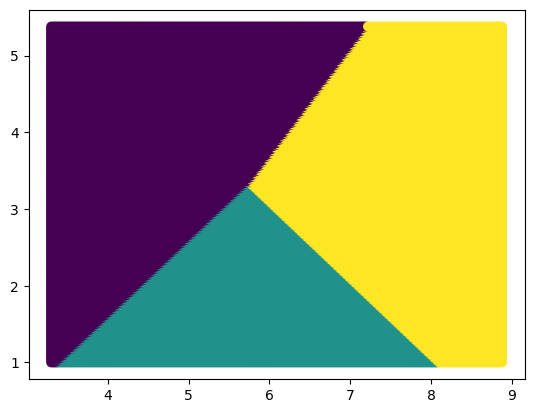

In [17]:
xx, yy = makegrid(x[:, 0], x[:, 1])
predictions = clf1.predict(np.c_[xx.ravel(), yy.ravel()])
plt.scatter(xx.ravel(), yy.ravel(), c = predictions)
plt.show()

Nonlinear SVM

In [18]:
clf = svm.SVC(gamma='auto') #RBF kernel
clf.fit(x_train,y_train)

SVC(gamma='auto')

In [19]:
clf.score(x_test,y_test)

0.8157894736842105

Decision Boundary using RBF or Gaussian kernel

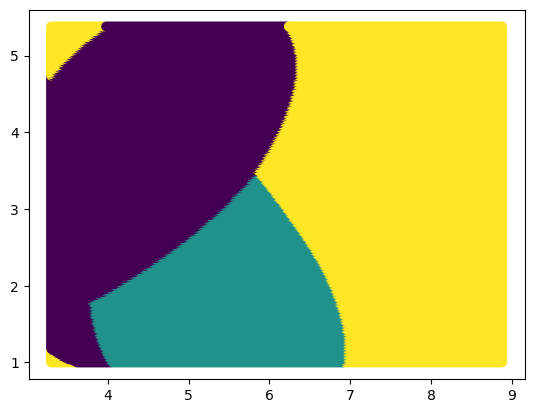

In [20]:
xx, yy = makegrid(x[:, 0], x[:, 1])
predictions = clf.predict(np.c_[xx.ravel(), yy.ravel()])
plt.scatter(xx.ravel(), yy.ravel(), c = predictions)
plt.show()

## 第二部分：回归任务（SVR）
结合搜索引擎阅读并理解以下代码。

使用不同的核值（线性SVR和非线性SVR）实现SVR学习算法。

回答问题：不同的核值之间有什么区别？

可选步骤：分别使用不同的“C”值和“gamma”值实现SVR学习算法。

In [21]:
from sklearn.svm import SVR
import matplotlib.pyplot as plt

In [22]:
# Generate sample data
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()

In [23]:
# Add noise to targets
y[::5] += 3 * (0.5 - np.random.rand(8))

In [24]:
svr_lin = SVR(kernel='linear', C=100, gamma='auto')
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_lin.fit(X,y)
svr_rbf.fit(X,y)

y_lin = svr_lin.predict(X)
y_rbf = svr_rbf.predict(X)

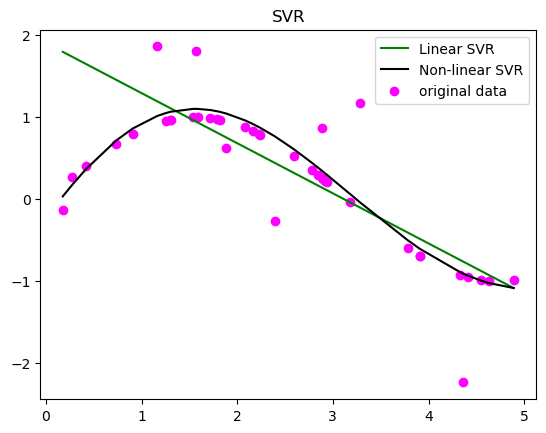

In [25]:
# Visualization
plt.plot(X, y_lin, color = 'green')
plt.plot(X, y_rbf, color = 'black')
plt.scatter(X,y,color = 'magenta')
plt.title('SVR')
plt.legend(['Linear SVR', 'Non-linear SVR', 'original data'])
plt.show()